In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [36]:
RAW_DIR = '../data/raw/'
PROCESSED_DIR = '../data/processed/'

FILES = {
    'ig_oas':    'convex-bamlc0a0cm-1825d.csv',
    'aaa_oas':   'convex-bamlc0a1caaa-1825d.csv',
    'aa_oas':    'convex-bamlc0a2caa-1825d.csv',
    'a_oas':     'convex-bamlc0a3ca-1825d.csv',
    'bbb_oas':   'convex-bamlc0a4cbbb-1825d.csv',
    'hy_oas':    'convex-bamlh0a0hym2-1825d.csv',
    'dgs1mo':   'convex-dgs1mo-1825d.csv',
    'dgs3mo':   'convex-dgs3mo-1825d.csv',
    'dgs6mo':   'convex-dgs6mo-1825d.csv',
    'dgs1':      'convex-dgs1-1825d.csv',
    'dgs2':      'convex-dgs2-1825d.csv',
    'dgs3':     'convex-dgs3-1825d.csv', 
    'dgs5':      'convex-dgs5-1825d.csv',
    'dgs10':     'convex-dgs10-1825d.csv',
    't10y2y':    'convex-t10y2y-1825d.csv',
    'fedfunds':  'convex-fedfunds-1825d.csv',
    'nfci':      'convex-nfci-1825d.csv',
    'stlfsi':    'convex-stlfsi4-1825d.csv',
    'vix':       'convex-vixcls-1825d.csv',
}

print("File mapping configured")
print(f"Total files: {len(FILES)}")

File mapping configured
Total files: 19


In [37]:
def load_convex_csv(filepath, col_name):
    """
    Load a Convex-format CSV file.
    Skips comment lines starting with #.
    Parses date column and renames value column.
    """
    df = pd.read_csv(
        filepath,
        comment='#',
        parse_dates=['date'],
        index_col='date'
    )
    df.columns = [col_name]
    return df

# Load all files
dfs = {}
for key, filename in FILES.items():
    filepath = os.path.join(RAW_DIR, filename)
    try:
        dfs[key] = load_convex_csv(filepath, key)
        print(f"OK  {key:10s}: {len(dfs[key])} rows | "
              f"{dfs[key].index.min().date()} to "
              f"{dfs[key].index.max().date()}")
    except Exception as e:
        print(f"FAIL {key}: {e}")

OK  ig_oas    : 1305 rows | 2021-05-24 to 2026-05-19
OK  aaa_oas   : 1306 rows | 2021-05-24 to 2026-05-19
OK  aa_oas    : 810 rows | 2023-04-18 to 2026-05-19
OK  a_oas     : 810 rows | 2023-04-18 to 2026-05-19
OK  bbb_oas   : 1306 rows | 2021-05-24 to 2026-05-19
OK  hy_oas    : 1306 rows | 2021-05-24 to 2026-05-19
OK  dgs1mo    : 1246 rows | 2021-05-27 to 2026-05-21
OK  dgs3mo    : 1246 rows | 2021-05-27 to 2026-05-21
OK  dgs6mo    : 1246 rows | 2021-05-27 to 2026-05-21
OK  dgs1      : 1247 rows | 2021-05-24 to 2026-05-19
OK  dgs2      : 1247 rows | 2021-05-24 to 2026-05-19
OK  dgs3      : 1246 rows | 2021-05-27 to 2026-05-21
OK  dgs5      : 1247 rows | 2021-05-24 to 2026-05-19
OK  dgs10     : 1247 rows | 2021-05-24 to 2026-05-19
OK  t10y2y    : 1248 rows | 2021-05-24 to 2026-05-20
OK  fedfunds  : 59 rows | 2021-06-01 to 2026-04-01
OK  nfci      : 260 rows | 2021-05-28 to 2026-05-15
OK  stlfsi    : 260 rows | 2021-05-28 to 2026-05-15
OK  vix       : 1282 rows | 2021-05-24 to 2026-05-19

In [38]:
# Concatenate all series along date axis
df = pd.concat(dfs.values(), axis=1)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Shape: (1333, 19)
Date range: 2021-05-24 to 2026-05-21

Missing values per column:
ig_oas        28
aaa_oas       27
aa_oas       523
a_oas        523
bbb_oas       27
hy_oas        27
dgs1mo        87
dgs3mo        87
dgs6mo        87
dgs1          86
dgs2          86
dgs3          87
dgs5          86
dgs10         86
t10y2y        85
fedfunds    1274
nfci        1073
stlfsi      1073
vix           51
dtype: int64


In [39]:
# AA and A OAS are excluded due to insufficient data history
df = df.drop(columns=['aa_oas', 'a_oas'])

# Forward-fill remaining missing values
df_filled = df.ffill()

# Drop rows where IG OAS is missing (use as anchor)
df_filled = df_filled.dropna(subset=['ig_oas'])

# Trim dataset to ensure no leading NaN rows (Fed Funds, NFCI, StLFSI begin 2021-06-01)
df_filled = df_filled.loc['2021-06-01':]

print(f"\nFinal shape: {df_filled.shape}")
print(f"Final date range: {df_filled.index.min().date()} to {df_filled.index.max().date()}")
print(f"\nRemaining missing values:")
print(df_filled.isnull().sum())


Final shape: (1327, 17)
Final date range: 2021-06-01 to 2026-05-21

Remaining missing values:
ig_oas      0
aaa_oas     0
bbb_oas     0
hy_oas      0
dgs1mo      0
dgs3mo      0
dgs6mo      0
dgs1        0
dgs2        0
dgs3        0
dgs5        0
dgs10       0
t10y2y      0
fedfunds    0
nfci        0
stlfsi      0
vix         0
dtype: int64


Raw OAS data from Convex is stored in percentage (%) form. Convert to bps for clarity.
Example: 0.76 represents 0.76% = 76 bps

Treasury yields and other rate series remain in percentage (%) form.

In [40]:
# Convert all OAS columns to basis points for consistency with market convention.

oas_cols = ['ig_oas', 'aaa_oas', 'bbb_oas', 'hy_oas']

print("Before conversion (percent form):")
print(df_filled[oas_cols].head(3).round(4))

for col in oas_cols:
    df_filled[col] = df_filled[col] * 100

print("\nAfter conversion (basis points):")
print(df_filled[oas_cols].head(3).round(2))

print("\nCurrent ranges (bps):")
for col in oas_cols:
    print(f"  {col:10s}: min={df_filled[col].min():.1f} "
          f"max={df_filled[col].max():.1f} "
          f"current={df_filled[col].iloc[-1]:.1f}")


Before conversion (percent form):
            ig_oas  aaa_oas  bbb_oas  hy_oas
date                                        
2021-06-01    0.91     0.46     1.13    3.33
2021-06-02    0.90     0.46     1.13    3.31
2021-06-03    0.90     0.47     1.13    3.28

After conversion (basis points):
            ig_oas  aaa_oas  bbb_oas  hy_oas
date                                        
2021-06-01    91.0     46.0    113.0   333.0
2021-06-02    90.0     46.0    113.0   331.0
2021-06-03    90.0     47.0    113.0   328.0

Current ranges (bps):
  ig_oas    : min=73.0 max=171.0 current=76.0
  aaa_oas   : min=27.0 max=82.0 current=34.0
  bbb_oas   : min=93.0 max=210.0 current=95.0
  hy_oas    : min=259.0 max=599.0 current=286.0


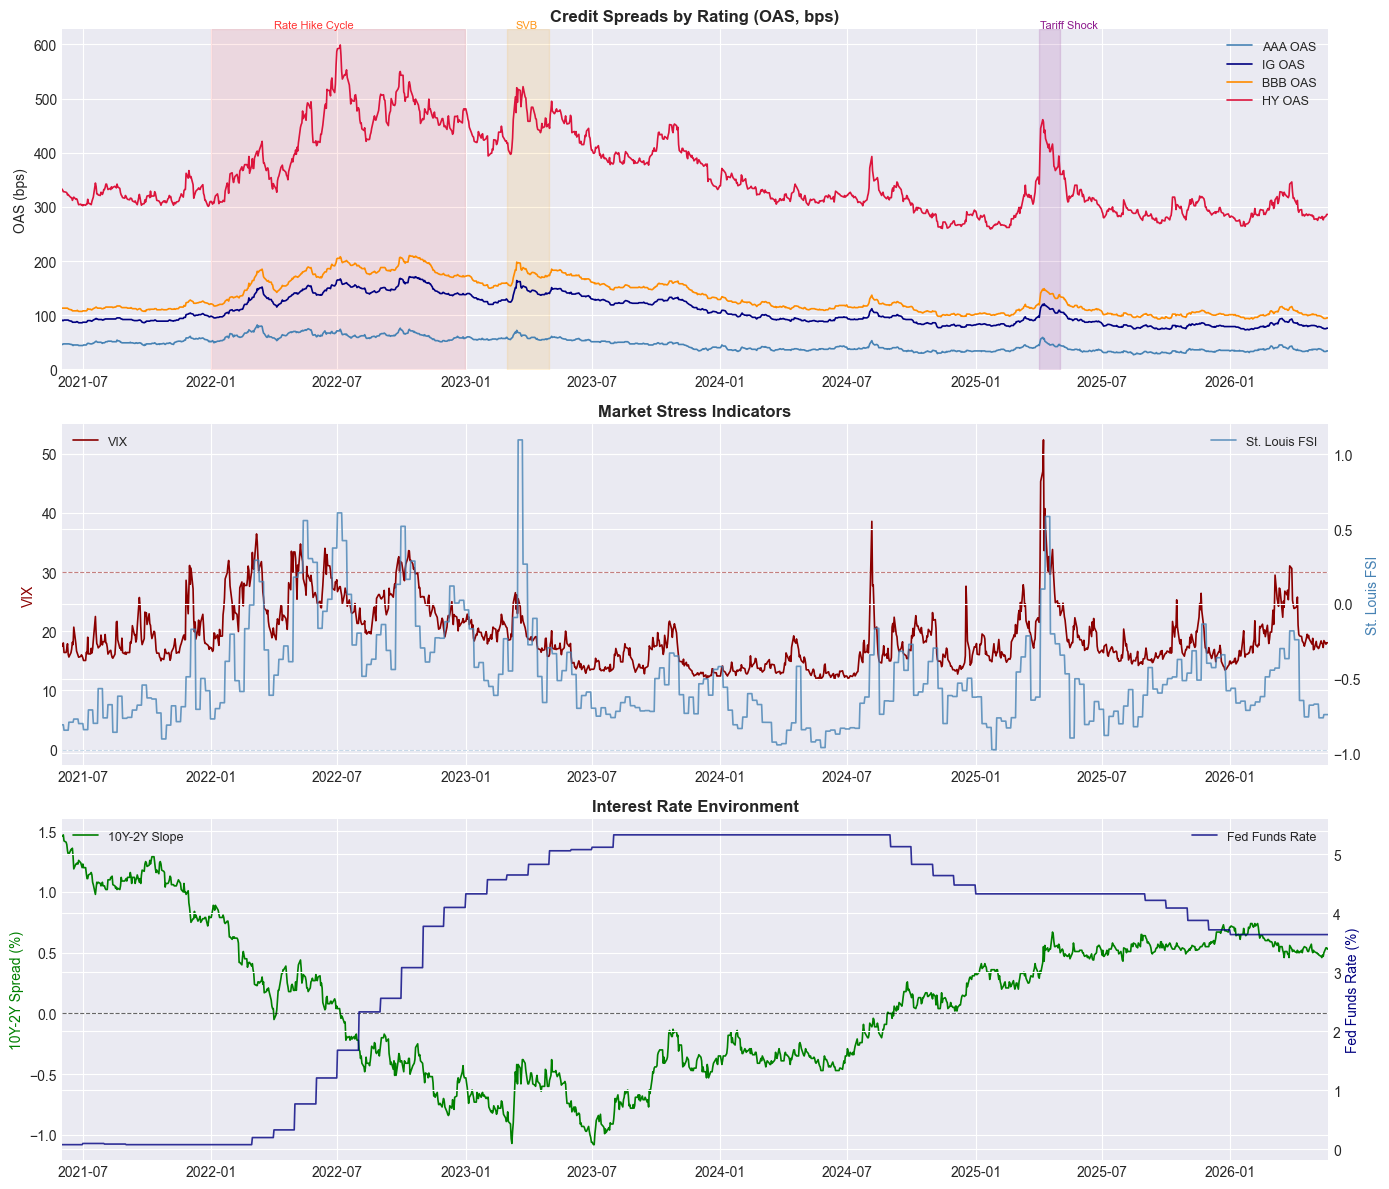

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Credit Spreads by Rating
ax1 = axes[0]

spread_series = {
    'AAA OAS': ('aaa_oas', 'steelblue'),
    'IG OAS':  ('ig_oas',  'navy'),
    'BBB OAS': ('bbb_oas', 'darkorange'),
    'HY OAS':  ('hy_oas',  'crimson'),
}

for label, (col, color) in spread_series.items():
    ax1.plot(df_filled.index, df_filled[col], label=label, color=color, linewidth=1.2)

# Shade key market events
ax1.axvspan('2022-01-01', '2022-12-31', alpha=0.08, color='red')
ax1.axvspan('2023-03-01', '2023-04-30', alpha=0.12, color='orange')
ax1.axvspan('2025-04-01', '2025-05-01', alpha=0.12, color='purple')

# Event labels
ymax = df_filled['hy_oas'].max() + 50
ax1.text(pd.Timestamp('2022-04-01'), ymax * 0.97, 'Rate Hike Cycle', fontsize=8, color='red', alpha=0.8)
ax1.text(pd.Timestamp('2023-03-13'), ymax * 0.97, 'SVB', fontsize=8, color='darkorange', alpha=0.9)
ax1.text(pd.Timestamp('2025-04-03'), ymax * 0.97, 'Tariff Shock', fontsize=8, color='purple', alpha=0.9)

ax1.set_title('Credit Spreads by Rating (OAS, bps)', fontsize=12, fontweight='bold')
ax1.set_ylabel('OAS (bps)')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(df_filled.index.min(), df_filled.index.max())

# Plot 2: Market Stress Indicators
ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.plot(df_filled.index, df_filled['vix'], color='darkred', label='VIX', linewidth=1.2)
ax2_twin.plot(df_filled.index, df_filled['stlfsi'],
              color='steelblue', label='St. Louis FSI', linewidth=1.2, alpha=0.8)

ax2.axhline(y=30, color='darkred', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axhline(y=0, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.3)

ax2.set_title('Market Stress Indicators', fontsize=12, fontweight='bold')
ax2.set_ylabel('VIX', color='darkred')
ax2_twin.set_ylabel('St. Louis FSI', color='steelblue')
ax2.legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)
ax2.set_xlim(df_filled.index.min(), df_filled.index.max())

# Plot 3: Interest Rate Environment
ax3 = axes[2]
ax3_twin = ax3.twinx()

ax3.plot(df_filled.index, df_filled['t10y2y'], color='green', label='10Y-2Y Slope', linewidth=1.2)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax3_twin.plot(df_filled.index, df_filled['fedfunds'],
              color='navy', label='Fed Funds Rate', linewidth=1.2, alpha=0.8)

ax3.set_title('Interest Rate Environment', fontsize=12, fontweight='bold')
ax3.set_ylabel('10Y-2Y Spread (%)', color='green')
ax3_twin.set_ylabel('Fed Funds Rate (%)', color='navy')
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)
ax3.set_xlim(df_filled.index.min(), df_filled.index.max())

plt.tight_layout()
plt.savefig('../data/processed/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

**Credit Spreads by Rating (OAS, bps)**

Credit spreads across all rating buckets follow a clear hierarchy throughout the sample: AAA < IG < BBB < HY, consistent with expected credit risk pricing.

During the 2022 rate hike cycle, spreads widened broadly across all rating categories, with HY OAS reaching a peak of approximately 600 bps. IG and BBB spreads also elevated but remained within historical norms.

The SVB stress event in March 2023 caused a brief but sharp spike across all spreads, most visibly in HY OAS, followed by a rapid normalization within weeks.

The 2025 tariff shock produced the most acute short-term dislocation in the sample, with HY OAS spiking above 450 bps before quickly retracing. IG and BBB spreads showed a more muted but still visible reaction.

As of May 2026, spreads have compressed to near the tightest levels in the sample window, with IG OAS at 76 bps and HY OAS at 286 bps, consistent with a risk-on environment.

**Market Stress Indicators**

Given that VIX values above 30 indicate greater market fear and uncertainty, while values below 20 suggest stability. As shown in sample dataset, VIX remained persistently elevated above the 30 threshold during the 2022 rate hike cycle, reflecting sustained macro uncertainty. The SVB event in March 2023 produced a brief VIX spike. The sharpest VIX reading in the entire sample occurred in April 2025, reaching approximately 50, coinciding with the tariff shock.

The St. Louis Financial Stress Index broadly tracks VIX, confirming that periods of elevated equity volatility correspond to genuine financial system stress rather than isolated equity market moves.

**Interest Rate Environment**

The Fed Funds rate rose from near zero in mid-2021 to approximately 5.5% by mid-2023, representing one of the most aggressive tightening cycles in recent history. Rate cuts began in late 2024, bringing the rate down to approximately 3.5% by end of sample.

The 10Y-2Y yield curve slope inverted sharply during 2022-2023, reaching nearly -1%, a level historically associated with recession risk. The curve subsequently normalized and turned positive again through 2025-2026.

In [42]:
output_path = os.path.join(PROCESSED_DIR, 'main_dataset.csv')
df_filled.to_csv(output_path)

print(f"Final shape: {df_filled.shape}")
print(f"Date range: {df_filled.index.min().date()} to {df_filled.index.max().date()}")
print(f"\nColumns saved:")
for col in df_filled.columns:
    print(f"  - {col}")

Final shape: (1327, 17)
Date range: 2021-06-01 to 2026-05-21

Columns saved:
  - ig_oas
  - aaa_oas
  - bbb_oas
  - hy_oas
  - dgs1mo
  - dgs3mo
  - dgs6mo
  - dgs1
  - dgs2
  - dgs3
  - dgs5
  - dgs10
  - t10y2y
  - fedfunds
  - nfci
  - stlfsi
  - vix
